## Import 

In [4]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt
import xrayutilities as xu
from scipy.interpolate import interpn
import pandas as pd
from scipy.stats import binned_statistic

from pyhectr import xrd_geom
from pyhectr import read_plot
from pyhectr import integration
from pyhectr import bragg_simulations as bs

%matplotlib widget

## Paths and experimental constants 

In [7]:
base_path = '/asap3/petra3/gpfs/p07/2022/data/11016526/raw/varex/'
InputDir = '/asap3/petra3/gpfs/p07/2022/data/11016526/raw/varex/'
OutputDir = '/asap3/petra3/gpfs/p07/2022/data/11016526/processed/processed_data/'
Experiments = sorted(next(os.walk(InputDir))[1])
Scan = Experiments[16]
img_path_pattern = InputDir + Scan + '/*[0-9].tif'

x0 = 1438  # center pixel, x
y0_init = 763 # center pixel, y
y0 = 2880 - y0_init
pix_size = 0.15
SDD = 1483.66
incidence_ang = 0.02
Lambda = 0.1680002615176152 # Angst, 73.8 keV

path_to_files = sorted(glob.glob(img_path_pattern))
ROIy = slice(0,2200) # vertical
ROIx = slice(0,2880) # horizontal
delta_ = xrd_geom.ROI_to_angle(ROIx, x0, pix_size, SDD)
gamma_ = xrd_geom.ROI_to_angle(ROIy, y0, pix_size, SDD) 

chi_ = 0.
phi_ = 0.
mu_ = incidence_ang 
mat = xu.materials.Al2O3 # choosing material from xrayutilities library
a = np.array([4.1171, -2.377, 0])
b = np.array([0, 4.754, 0])
c = np.array([0, 0, 12.99])
pi = np.pi


## Loading data for integration

In [8]:
#load data 
data, omes_with_z = read_plot.read_P07_imgs_with_metadata(img_path_pattern, ROIx, ROIy)  

In [9]:
# load theta
load_theta = True
if load_theta:
    mask_filenm = f'{Scan}_theta_adjusted.npy'
    outfile = OutputDir + f'{mask_filenm}'
    print(f'\n...loading theta - {mask_filenm}\n')
    theta_ang = np.load(outfile)
    print(f'\n...file { mask_filenm } loaded, done \n')


...loading theta - pure_al2o3_00001_theta_adjusted.npy


...file pure_al2o3_00001_theta_adjusted.npy loaded, done 



In [10]:
# load reciprocal space
load_hkl = True
if load_hkl:
    mask_filenm = f'{Scan}_h_arr.npy'
    outfile = OutputDir + f'{mask_filenm}'
    print(f'\n...loading masks - {mask_filenm}\n')
    h = np.load(outfile)
    print(f'\n ...file { mask_filenm } loaded, done \n')

    mask_filenm = f'{Scan}_k_arr.npy'
    outfile = OutputDir + f'{mask_filenm}'
    print(f'\n...loading masks - {mask_filenm}\n')
    k = np.load(outfile)
    print(f'\n ...file { mask_filenm } loaded, done \n')

    mask_filenm = f'{Scan}_l_arr.npy'
    outfile = OutputDir + f'{mask_filenm}'
    print(f'\n...loading masks - {mask_filenm}\n')
    l = np.load(outfile)
    print(f'\n ...file { mask_filenm } loaded, done \n')


...loading masks - pure_al2o3_00001_h_arr.npy


 ...file pure_al2o3_00001_h_arr.npy loaded, done 


...loading masks - pure_al2o3_00001_k_arr.npy


 ...file pure_al2o3_00001_k_arr.npy loaded, done 


...loading masks - pure_al2o3_00001_l_arr.npy


 ...file pure_al2o3_00001_l_arr.npy loaded, done 



In [159]:
#load masks
load = True
if load:
    mask_filenm = f'P07_{Scan}_Mask.npy'
    outfile = OutputDir + f'{mask_filenm}'
    print(f'\n...loading masks - {mask_filenm}\n')
    Mask = np.load(outfile)
    print(f'\n...file { mask_filenm } loaded, done \n')


...loading masks - P07_pure_al2o3_00001_Mask.npy


...file P07_pure_al2o3_00001_Mask.npy loaded, done 



In [12]:
#load beamstops mask 
mask_filenm = f'{Scan}_detected_beamstops.npy'
outfile = OutputDir + f'{mask_filenm}'

print(f'\n...loading file - {mask_filenm}\n')
beamstops_mask = np.load(outfile)
print(f'\n ...file { mask_filenm } loaded, done \n')


...loading file - pure_al2o3_00001_detected_beamstops.npy


 ...file pure_al2o3_00001_detected_beamstops.npy loaded, done 



In [ ]:
plt.figure()
plt.imshow(beamstops_mask, vmin=0, vmax=255)
plt.show()

In [14]:
max_mask = read_plot.max_pxl_im(Mask)
max_pxl_im = read_plot.max_pxl_im(data)

In [ ]:
%matplotlib widget
plt.figure()
plt.imshow(Mask[301], vmax=1)
plt.axis('off')
plt.show()

In [ ]:
%matplotlib widget
fig, ax = plt.subplot_mosaic([
    ['maxim', 'maxmsk', 'bsmsk']  ], figsize=(10, 5))
ax['maxim'].imshow(max_pxl_im, vmax=220)
ax['maxmsk'].imshow(max_mask, vmax=1)
ax['maxim'].set_title('Max pixel image')
ax['maxmsk'].set_title('Max pixel CTRs mask')
ax['bsmsk'].imshow(beamstops_mask, vmax=1)
ax['bsmsk'].set_title('Beam stops mask')
for _a in ax.values():
    _a.set_axis_off()
fig.savefig('max_im_max_mask_bsmsk.pdf')
plt.show()

## Q space

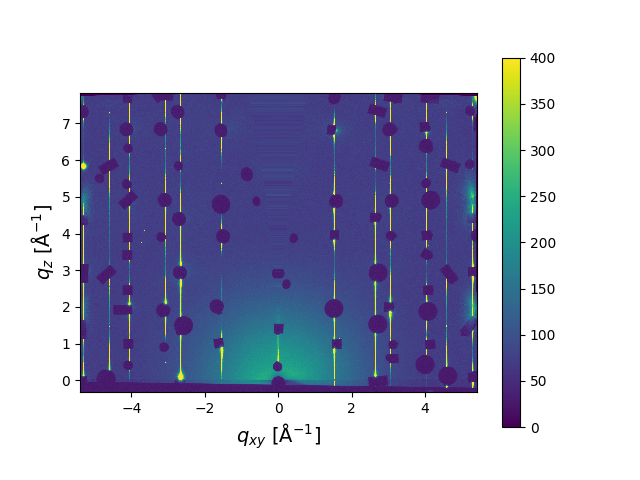

In [17]:
# plotting
font1 = {'family':'sans-serif','color':'black','size':14}

x, y, RR_r, RR_z, q_r, q_z = xrd_geom.Q_grid2(ROIx, ROIy, pix_size, SDD, Lambda, x0, y0, incidence_ang)
im_grid = interpn((x, y), max_pxl_im.T, (RR_r, RR_z), method = 'linear', bounds_error = False, fill_value = 0)

fig, ax = plt.subplots()
img = ax.pcolormesh(q_r, q_z, im_grid, vmin=0, vmax=4e2)#norm=colors.LogNorm(vmin=1e1, vmax=1e))
q_img = img.get_array()
q_img = np.rot90(q_img, k=2)
plt.gca().set_aspect('equal')
ax.set_xlabel('$q_{xy}$ [$\mathrm{\AA}^{-1}$]', fontdict = font1)
ax.set_ylabel('$q_{z}$ [$\mathrm{\AA}^{-1}$]', fontdict = font1)
fig.colorbar(img, ax=ax, orientation='vertical')

# for d in (2.3337, 1.6502, 1.3474, 1.1669, 1.0437, 0.9527, 0.8821, 0.7779, 0.738):
#     radius = 2 * np.pi / d
#     circle1 = plt.Circle((0, 0), 2*np.pi/d, color='r', fill=False, linewidth = .7, linestyle = '--' )
#     ax.add_patch(circle1)
#     ax.text(0, radius + 0.1, f'd = {d:.4f}', color='blue', fontsize=10, ha='center')

# ylims = ax.get_ylim()
# ax.set_ylim(0,ylims[1])
ax.set_aspect(1)
#fig.savefig('plotcircles.png')
plt.show()

In [18]:
volume = xrd_geom.triple_product(a, b, c)
c_star = 2*pi*xrd_geom.reciprocal_vec(a, b, volume)
a_star = 2*pi*xrd_geom.reciprocal_vec(b, c, volume)
b_star = 2*pi*xrd_geom.reciprocal_vec(c, a, volume)

In [19]:
L_arr = q_z/c_star[2]
q_r, q_z, L_arr

(array([-5.39700451, -5.39328244, -5.38956036, ...,  5.40072658,
         5.40444865,  5.40817072]),
 array([-0.31265405, -0.30893198, -0.30520991, ...,  7.8237955 ,
         7.82751757,  7.83123965]),
 array([-0.64638809, -0.638693  , -0.6309979 , ..., 16.1750925 ,
        16.1827876 , 16.1904827 ]))

In [20]:
L_interpol = np.arange(L_arr.min(), L_arr.max(), (L_arr.max() - L_arr.min())/data.shape[1])
len(L_interpol), L_interpol

(2200,
 array([-0.64638809, -0.63873497, -0.63108185, ..., 16.16752333,
        16.17517645, 16.18282957]))

In [21]:
# CTR integration window parameters

bin_gamma_rate = 15
half_omega_r   = 8
half_delta_r   = 18
medfilt_kernel = 51   # used when flag='medfilt'
FLAG           = 'median'                 

In [23]:
# γ-bin edges/centres
gamma_pxl_range = data.shape[1]
gamma_edges   = np.arange(0, gamma_pxl_range + bin_gamma_rate, bin_gamma_rate)
gamma_centres = (gamma_edges[:-1] + gamma_edges[1:]) // 2

y_pix = ROIy.start + gamma_centres
y_rel = y0 - y_pix

q_z_bins = 4 * np.pi / Lambda * np.sin(0.5 * np.arctan(y_rel * pix_size / SDD))[::-1]
Q_binned = q_z_bins
L_binned = q_z_bins / c_star[2]
d_L_binned = (np.diff(L_binned)).mean()

In [24]:
len(L_binned)

147

In [ ]:
read_plot.image_mask_slider(data, Mask, vmax_im1 = 110, vmax_im2 = 1, fig_size=(7, 5));

## Rods integration

### [2, 2, L]

In [26]:
Bragg_peak = (2, 2, None)

# creating folders 
rod_name = f'{Bragg_peak[0]}{Bragg_peak[1]}'
dir_name = 'P07_sapphire/rod|' + rod_name
path_to_dir = 'CTR_processed/'
dir_name_gamma = dir_name + '/before_correction/images/' + 'gamma_check/'

create = True
if create:
    read_plot.rod_create_nested_folders(dir_n = dir_name, path = path_to_dir, gamma_check = True)

In [27]:
pwd

'/home/batraevr/Projecrts/3/P07_Luis_2024/data_integration'

In [ ]:
x_left = 2820
x_right = 2880
pixel_coord, rod_masked = integration.rod_points_prep(mask_arr = Mask, x_l = x_left, x_r = x_right)
l_coord = np.median(l[:, :, x_left:x_right], axis=(0,2))

In [ ]:
current_beamstops_mask = beamstops_mask.copy()
current_beamstops_mask[:, :x_left] = 0
current_beamstops_mask[:, x_right:] = 0

plt.figure()
plt.imshow(current_beamstops_mask, vmin=0, vmax=255) 
plt.show()

In [ ]:
fig, ax = plt.subplot_mosaic([
    ['maxim', 'rodmsk', 'bmstp']  ], figsize=(13, 6))
ax['maxim'].imshow(max_pxl_im, vmax=220)
ax['rodmsk'].imshow(rod_masked, vmax=1)
ax['bmstp'].imshow(current_beamstops_mask, vmax=1)

ax['maxim'].set_title('Max pixel image')
ax['rodmsk'].set_title('Rod mask')
ax['bmstp'].set_title('Beam stops mask')
for _a in ax.values():
    _a.set_axis_off()
fig.savefig('all_masks_rod22L.pdf')
# fig.savefig(path_to_dir + dir_name + '/before_correction/images/integration_overview.png')

In [31]:
gamma_threshold = 0.05
if gamma_threshold is not None:
    gamma_threshold_index = integration.find_closest_value_index(gamma_, gamma_threshold)
    gamma_mask = gamma_ > gamma_[gamma_threshold_index]
    gamma_thresholded = gamma_[gamma_mask]
    pixel_coord_plot= pixel_coord[pixel_coord[:, 1] < gamma_threshold_index]
    l_coord = np.median(l[:, :, x_left:x_right], axis=(0,2))
    l_coord = l_coord[gamma_mask]
    gamma_shape = gamma_thresholded.shape[0]

In [33]:
y_pixels = np.array(list((set(pixel_coord_plot[:, 1]))))

signal_direction_sign = integration.signal_direction(y_pixels)
signal_direction_sign 

-1

In [ ]:
images_n = integration.get_signal_image_range(pixel_coord_plot)
images_n 

In [ ]:
integration.get_delta_range(pixel_coord_plot=pixel_coord_plot, 
                gamma_pxl_range = gamma_pxl_range, 
                plot_flag = True, 
                sigma_factor = 1)

In [ ]:
omega_half_range = integration.get_omega_range(pixel_coord_plot = pixel_coord_plot, 
                                                gamma_pxl_range = gamma_pxl_range, 
                                                plot_flag = True, 
                                                sigma_factor = 1)
omega_half_range

In [37]:
Ctot_full = integration.apply_corrections2D(delta_, gamma_, incidence_ang , rocking = True, return_map =True)

# tmp1 = mask_11 * data
tmp1 = data
tmp1 = tmp1  / Ctot_full[None, :, :]

n_image = 177
delta_mid = 2844
g0 =np.int64(0), g1 =np.int64(15)


n_image = 177
delta_mid = 2845
g0 =np.int64(15), g1 =np.int64(30)


n_image = 177
delta_mid = 2845
g0 =np.int64(30), g1 =np.int64(45)


n_image = 176
delta_mid = 2846
g0 =np.int64(45), g1 =np.int64(60)


n_image = 176
delta_mid = 2845
g0 =np.int64(60), g1 =np.int64(75)


n_image = 175
delta_mid = 2846
g0 =np.int64(75), g1 =np.int64(90)


n_image = 175
delta_mid = 2846
g0 =np.int64(90), g1 =np.int64(105)


n_image = 174
delta_mid = 2846
g0 =np.int64(105), g1 =np.int64(120)


n_image = 174
delta_mid = 2846
g0 =np.int64(120), g1 =np.int64(135)


n_image = 173
delta_mid = 2847
g0 =np.int64(135), g1 =np.int64(150)


n_image = 173
delta_mid = 2847
g0 =np.int64(150), g1 =np.int64(165)


n_image = 172
delta_mid = 2847
g0 =np.int64(165), g1 =np.int64(180)


n_image = 172
delta_mid = 2847
g0 =np.int64(180), g1 =np.int64(195)


n_image = 171
delta_mid = 2847
g0 =np.int64(195), g1 =np.int64(210)


n_image = 171
delta_mid = 2847
g0 

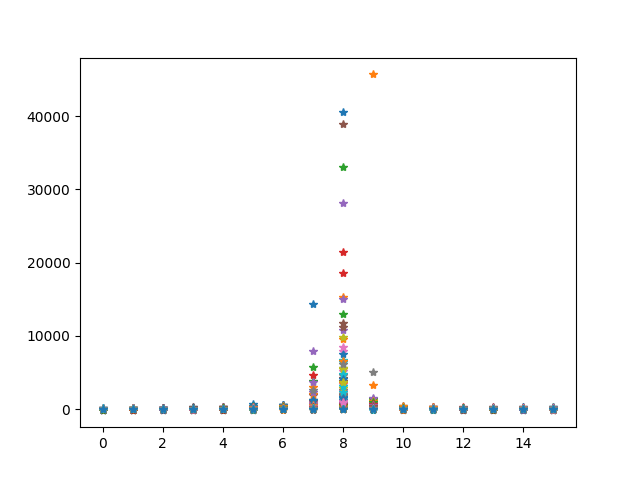

In [39]:
_output = integration.rocking_scan_integration(tmp1 , pixel_coord_plot, half_omega_r, half_delta_r,
                                   bin_gamma_rate, gamma_edges, gamma_centres, 
                                   FLAG = 'median', medfilt_kernel = 51, 
                                   SHOW_PLOT = True, PRINT_INTEGRATION_INFO = True)

# intensities_summed, int_slider_raw, int_slider_subtracted, bckgd_slider, omega_windows, gamma_windows = np.array(_output)
len(_output)
intensities_summed, int_slider_raw, int_slider_subtracted, bckgd_slider, omega_windows, gamma_windows, delta_windows = _output

In [40]:
len(intensities_summed), len(int_slider_raw), len(int_slider_subtracted), len(bckgd_slider), len(omega_windows), len(gamma_windows), len(delta_windows)

(147, 147, 147, 147, 141, 141, 141)

In [41]:
intensities_summed = np.array(intensities_summed, dtype='float32')[::signal_direction_sign ]

len(Q_binned), len(L_binned), len(intensities_summed), d_L_binned

(147, 147, 147, np.float64(0.11538604000982763))

In [42]:
np_int_slider_raw   = [np.asarray(i) for i in int_slider_raw   if i is not None]
np_int_bckgd_subtr  = [np.asarray(i) for i in int_slider_subtracted if i is not None]
np_bckgd_slider     = [np.asarray(i) for i in bckgd_slider     if i is not None]

In [44]:
gamma_windows_fullrange = [(i, min(i+bin_gamma_rate, data.shape[1])) for i in range(0, data.shape[1], bin_gamma_rate)]

gamma_mask = np.isin(np.array(gamma_windows_fullrange), np.array(gamma_windows)).all(axis=1)#[::signal_direction_sign]

In [46]:
gamma_mask = np.array(intensities_summed) > 0   # 
L_values = L_binned[::signal_direction_sign][gamma_mask]

In [47]:
d_L_binned, (np.diff(Q_binned / c_star[2])).mean()

(np.float64(0.11538604000982763), np.float64(0.11538604000982763))


... saving gif ... 

... done ... 



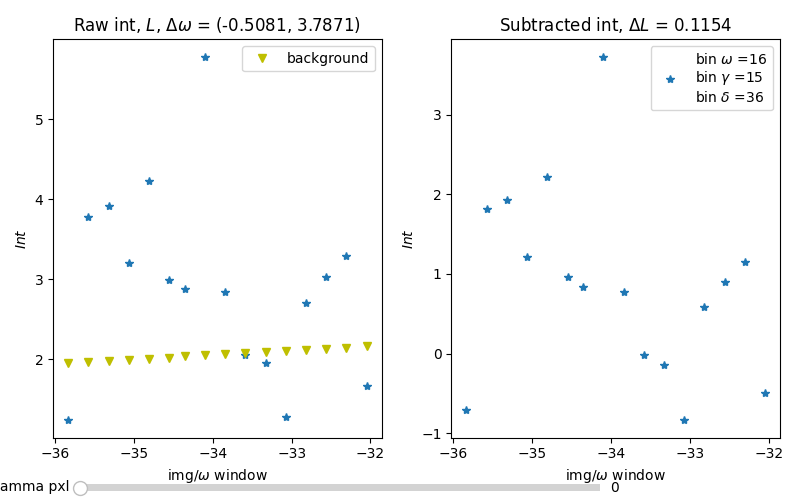

In [50]:
movie_path = path_to_dir + dir_name + '/before_correction/images/' + 'rocking_animation_' + f'bin_gamma_{bin_gamma_rate}_' + '.gif'
movie_path

bin_omega_rate = 2 * half_omega_r
bin_delta_rate = 2 * half_delta_r
theta_         = theta_ang                   

read_plot.om_profile_slider(np_int_slider_raw, np_int_bckgd_subtr, np_bckgd_slider,
                  omega_values=theta_, omega_windows=omega_windows,
                  L_values=L_binned[::signal_direction_sign][gamma_mask],
                  gamma_windows=gamma_windows,
                  bin_omega_rate=bin_omega_rate,
                  bin_gamma_rate=bin_gamma_rate,
                  bin_delta_rate=bin_delta_rate,
                  l_bin_rate=d_L_binned,
                  save_animate=True,
                  movie_path = movie_path,
                  fig_size=(8, 5));

In [ ]:
params_d = {
    'gamma_bin_rate_pxl': bin_gamma_rate, 
    'omega_window_imgs': bin_omega_rate, 
    'delta_window_pxl': bin_delta_rate
}

I_sqrt = np.sqrt(intensities_summed)
fig, ax = plt.subplots(figsize=(10, 5))
err_poisson = read_plot.I_error(I_sqrt, f_low = 0.20, f_high = 0.1, gamma = 1, mode = "poisson")

# Plot with error bars
ax.errorbar(
    L_binned, I_sqrt, yerr=err_poisson, fmt='*', capsize=5,
    label=f'Rod {Bragg_peak[0], Bragg_peak[1]}L, Structure Factor'
)

# Labels
ax.set_xlabel(r'$L$')
ax.set_ylabel(r'$\sqrt{I}$')

# Combine Bragg peak info and parameters into a single title
bragg_info = f'ROD: [{Bragg_peak[0]}{Bragg_peak[1]}L]'
formatted_params = ', '.join([f"{k}: {v:.2f}" for k, v in params_d.items()])  # Format each parameter on a new line
title = f"{bragg_info}\n{formatted_params}"

ax.set_title(title, fontsize=10)  # Adjust fontsize if needed
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

# save_figs_dir = path_to_dir + dir_name + '/before_correction/images'

# if save_figs_dir is not None:
#     plt.savefig(f'{save_figs_dir}/rod{rod_name}L.png')

In [52]:
row_fraction = current_beamstops_mask[:, x_left:x_right].astype(bool).mean(axis=1)[::signal_direction_sign]   

bin_frac, bin_edges, binnumber = binned_statistic(
        x      = np.arange(current_beamstops_mask.shape[0]),
        values = row_fraction,
        statistic = 'mean',
        bins   = gamma_edges)  

delta_binned, _, _ = binned_statistic(
    pixel_coord_plot[:,1],    # the values to bin by
    pixel_coord_plot[:,2],    # the δ-pixels
    statistic='median',
    bins=gamma_edges
                    )

theta_binned, _, _ = binned_statistic(
    pixel_coord_plot[:,1],
    pixel_coord_plot[:,0],
    statistic='median',
    bins=gamma_edges
                    ) 

delta_binned = delta_binned[::signal_direction_sign] 
theta_binned = theta_binned[::signal_direction_sign] 


threshold = 0.01   # drop bins that are ≥threshold % masked
keep = bin_frac < threshold

In [53]:
# Ensure all arrays have identical length
assert keep.size == I_sqrt.size == L_binned.size

# NaN (or a NumPy masked array) so Matplotlib skips these bins
I_sqrt_clean = I_sqrt.copy()
# I_clean[~keep[::signal_direction_sign] ] = np.nan         # or:  I_clean = np.ma.array(I_sqrt, mask=~keep)
I_sqrt_clean[~keep] = np.nan

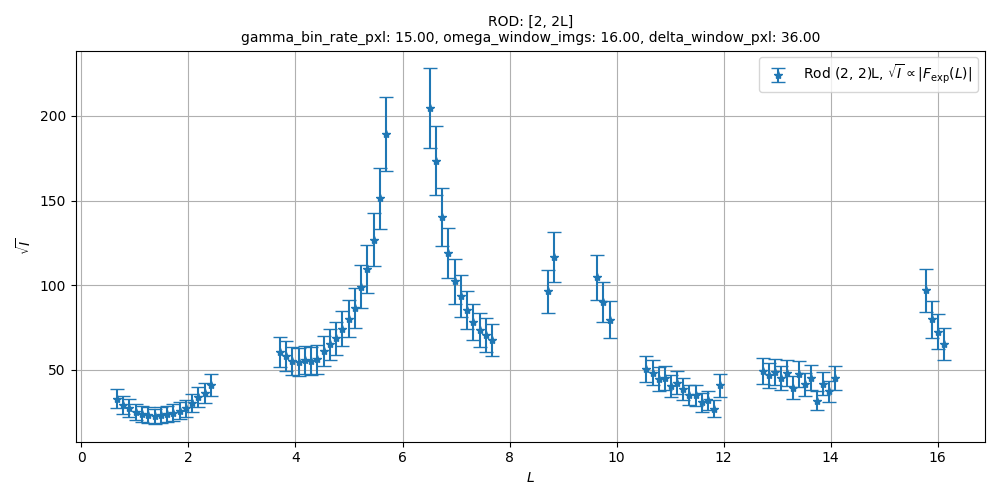

In [54]:
params_d = {
    'gamma_bin_rate_pxl': bin_gamma_rate, 
    'omega_window_imgs': bin_omega_rate, 
    'delta_window_pxl': bin_delta_rate
}

fig, ax = plt.subplots(figsize=(10, 5))
err_poisson = read_plot.I_error(I_sqrt_clean, f_low = 0.20, f_high = 0.1, gamma = 1, mode = "poisson")

# Plot with error bars
ax.errorbar(
    L_binned, I_sqrt_clean, yerr=err_poisson, fmt='*', capsize=5,
    label = f'Rod ({Bragg_peak[0]}, {Bragg_peak[1]})L, 'r'$\sqrt{I} \propto |F_{\mathrm{exp}}(L)|$')

# Labels
ax.set_xlabel(r'$L$')
ax.set_ylabel(r'$\sqrt{I}$')

# Combine Bragg peak info and parameters into a single title
bragg_info = f'ROD: [{Bragg_peak[0]}, {Bragg_peak[1]}L]'
formatted_params = ', '.join([f"{k}: {v:.2f}" for k, v in params_d.items()])  # Format each parameter on a new line
title = f"{bragg_info}\n{formatted_params}"

ax.set_title(title, fontsize=10)  # Adjust fontsize if needed
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

# save_figs_dir = path_to_dir + dir_name + '/after_correction/images'

# if save_figs_dir is not None:
#     plt.savefig(f'{save_figs_dir}/rod{rod_name}L.png')
#     plt.savefig(f'{save_figs_dir}/rod{rod_name}L.pdf')
#     plt.savefig(f'{save_figs_dir}/rod{rod_name}L.svg')

In [55]:
L_binned_22 = L_binned.copy()
I_sqrt_clean_22 = I_sqrt_clean.copy()

In [56]:
H = np.array([Bragg_peak[0]]*len(I_sqrt_clean))
K = np.array([Bragg_peak[1]]*len(I_sqrt_clean))
intensity_mask = I_sqrt_clean > 0

gamma_binned = gamma_[gamma_centres][::signal_direction_sign]
corr_tot_corr2save = Ctot_full[gamma_centres][::signal_direction_sign]

delta_2save = delta_[delta_binned[intensity_mask].astype(int)]
theta_2save = theta_[theta_binned[intensity_mask].astype(int)]


sfactor_data_merged = {"H": H[intensity_mask], 
                       "K": K[intensity_mask],
                       "L": L_binned[intensity_mask],
                       "F": I_sqrt_clean[intensity_mask],
                       "Error": err_poisson[intensity_mask],
                       # "delta": delta_2save,
                       # "gamma": gamma_binned[intensity_mask],
                       # "theta": theta_2save,
                       # "C_tot": corr_tot_corr2save[intensity_mask]
                      }

In [57]:
df2save = pd.DataFrame(data=sfactor_data_merged)
df2save.head(50)

,H,K,L,F,Error
0,2,2,0.664451,33.082989,5.778901
1,2,2,0.781699,29.376175,5.344616
2,2,2,0.898942,27.508865,5.122060
3,2,2,1.016182,25.174469,4.839576
4,2,2,1.133415,24.220423,4.722585
5,2,2,1.250643,23.238672,4.601156
6,2,2,1.367865,22.620739,4.524148
7,2,2,1.485079,23.307838,4.609747
8,2,2,1.602286,24.115013,4.709599
9,2,2,1.719484,24.848152,4.799668


In [58]:
df2save

,H,K,L,F,Error
0,2,2,0.664451,33.082989,5.778901
1,2,2,0.781699,29.376175,5.344616
2,2,2,0.898942,27.508865,5.122060
3,2,2,1.016182,25.174469,4.839576
4,2,2,1.133415,24.220423,4.722585
...,...,...,...,...,...
75,2,2,14.088320,45.264229,7.155824
76,2,2,15.774232,97.137848,12.660076
77,2,2,15.886037,79.836166,10.858947
78,2,2,15.997766,72.645866,10.103134


In [68]:
df2save.to_csv(
    f"CTR_processed/P07_sapphire/integrated_rods/rod|{Bragg_peak[0]}{Bragg_peak[1]}L.txt",
    sep=" ",
    index=False,
    float_format="%.8f",
    encoding="utf-8"
)

### [3, 0, L]; 0-65 img range

In [61]:
Bragg_peak = (3, 0, None)

# creating folders 
rod_name = f'{Bragg_peak[0]}{Bragg_peak[1]}'
dir_name = 'P07_sapphire/rod|' + rod_name
path_to_dir = 'CTR_processed/'
dir_name_gamma = dir_name + '/before_correction/images/' + 'gamma_check/'

create = True
if create:
    read_plot.rod_create_nested_folders(dir_n = dir_name, path = path_to_dir, gamma_check = True)

In [ ]:
x_left = 2635
x_right = 2740
pixel_coord, rod_masked  = integration.rod_points_prep(mask_arr = Mask, x_l = x_left, x_r = x_right)
l_coord = np.median(l[:, :, x_left:x_right], axis=(0,2))

In [ ]:
current_beamstops_mask = beamstops_mask.copy()
current_beamstops_mask[:, :x_left] = 0
current_beamstops_mask[:, x_right:] = 0

plt.figure()
plt.imshow(current_beamstops_mask, vmin=0, vmax=255) 
plt.show()

In [ ]:
# max_mask = read_plot.max_pxl_im(Mask)
# max_pxl_im = read_plot.max_pxl_im(data)

fig, ax = plt.subplot_mosaic([
    ['maxim', 'rodmsk', 'bmstp']  ], figsize=(13, 6))
ax['maxim'].imshow(max_pxl_im, vmax=220)
ax['rodmsk'].imshow(rod_masked, vmax=1)
ax['bmstp'].imshow(current_beamstops_mask, vmax=1)

ax['maxim'].set_title('Max pixel image')
ax['rodmsk'].set_title('Max pixel rod mask')
ax['bmstp'].set_title('Beam stops mask')
fig.savefig(path_to_dir + dir_name + '/before_correction/images/integration_overview.pdf')
fig.savefig(path_to_dir + dir_name + '/before_correction/images/integration_overview.svg')

In [65]:
gamma_threshold = 0.05
if gamma_threshold is not None:
    gamma_threshold_index = integration.find_closest_value_index(gamma_, gamma_threshold)
    gamma_mask = gamma_ > gamma_[gamma_threshold_index]
    gamma_thresholded = gamma_[gamma_mask]
    pixel_coord_plot= pixel_coord[pixel_coord[:, 1] < gamma_threshold_index]
    l_coord = np.median(l[:, :, x_left:x_right], axis=(0,2))
    l_coord = l_coord[gamma_mask]
    gamma_shape = gamma_thresholded.shape[0]

In [67]:
y_pixels = np.array(list((set(pixel_coord_plot[:, 1]))))

signal_direction_sign = integration.signal_direction(y_pixels)
signal_direction_sign 

-1

In [ ]:
images_n = integration.get_signal_image_range(pixel_coord_plot)
images_n 

In [69]:
split_image = images_n[np.diff(images_n).argmax()+1] - images_n[np.diff(images_n).argmax()-1]
images_n = np.unique(pixel_coord[:, 0])
images_n = images_n[(images_n < split_image)]
pixel_coord_plot = pixel_coord[pixel_coord[:, 0] < split_image]

In [70]:
y_pixels = np.array(list((set(pixel_coord_plot[:, 1]))))

signal_direction_sign = integration.signal_direction(y_pixels)
signal_direction_sign 

-1

In [ ]:
images_n = integration.get_signal_image_range(pixel_coord_plot)
images_n 

In [ ]:
integration.get_delta_range(pixel_coord_plot=pixel_coord_plot, 
                gamma_pxl_range = gamma_pxl_range, 
                plot_flag = True, 
                sigma_factor = 1)

In [ ]:
omega_half_range = integration.get_omega_range(pixel_coord_plot = pixel_coord_plot, 
                                                gamma_pxl_range = gamma_pxl_range, 
                                                plot_flag = True, 
                                                sigma_factor = 1)
omega_half_range

In [74]:
Ctot_full = integration.apply_corrections2D(delta_, gamma_, incidence_ang , rocking = True, return_map =True)

tmp1 = data
tmp1 = tmp1  / Ctot_full[None, :, :]

n_image = 61
delta_mid = 2651
g0 =np.int64(0), g1 =np.int64(15)


n_image = 60
delta_mid = 2651
g0 =np.int64(15), g1 =np.int64(30)


n_image = 60
delta_mid = 2652
g0 =np.int64(30), g1 =np.int64(45)


n_image = 59
delta_mid = 2652
g0 =np.int64(45), g1 =np.int64(60)


n_image = 58
delta_mid = 2652
g0 =np.int64(60), g1 =np.int64(75)


n_image = 58
delta_mid = 2653
g0 =np.int64(75), g1 =np.int64(90)


n_image = 57
delta_mid = 2653
g0 =np.int64(90), g1 =np.int64(105)


n_image = 57
delta_mid = 2653
g0 =np.int64(105), g1 =np.int64(120)


n_image = 56
delta_mid = 2654
g0 =np.int64(120), g1 =np.int64(135)


n_image = 56
delta_mid = 2654
g0 =np.int64(135), g1 =np.int64(150)


n_image = 55
delta_mid = 2654
g0 =np.int64(150), g1 =np.int64(165)


n_image = 55
delta_mid = 2654
g0 =np.int64(165), g1 =np.int64(180)


n_image = 54
delta_mid = 2655
g0 =np.int64(180), g1 =np.int64(195)


n_image = 54
delta_mid = 2655
g0 =np.int64(195), g1 =np.int64(210)


n_image = 53
delta_mid = 2655
g0 =np.int64(210),

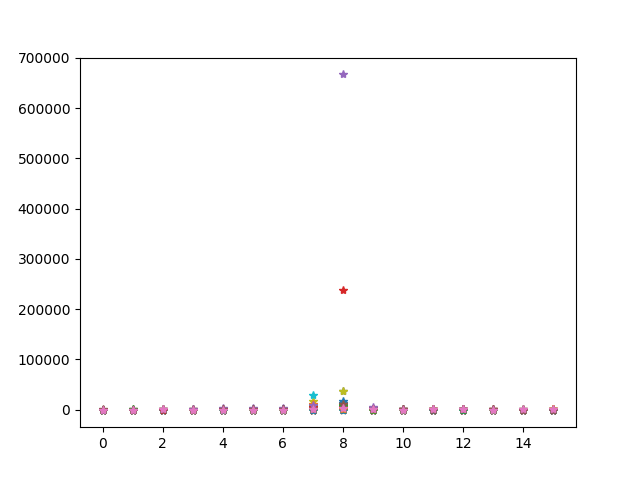

In [76]:
_output = integration.rocking_scan_integration(tmp1 , pixel_coord_plot, half_omega_r, half_delta_r,
                                   bin_gamma_rate, gamma_edges, gamma_centres, 
                                   FLAG = 'median', medfilt_kernel = 51, 
                                   SHOW_PLOT = True, PRINT_INTEGRATION_INFO = True)

# intensities_summed, int_slider_raw, int_slider_subtracted, bckgd_slider, omega_windows, gamma_windows = np.array(_output)
len(_output)
intensities_summed, int_slider_raw, int_slider_subtracted, bckgd_slider, omega_windows, gamma_windows, delta_windows = _output

In [77]:
len(intensities_summed), len(int_slider_raw), len(int_slider_subtracted), len(bckgd_slider), len(omega_windows), len(gamma_windows), len(delta_windows)

(147, 147, 147, 147, 147, 147, 147)

In [78]:
intensities_summed = np.array(intensities_summed, dtype='float32')[::signal_direction_sign ]

len(Q_binned), len(L_binned), len(intensities_summed), d_L_binned

(147, 147, 147, np.float64(0.11538604000982763))

In [79]:
np_int_slider_raw   = [np.asarray(i) for i in int_slider_raw   if i is not None]
np_int_bckgd_subtr  = [np.asarray(i) for i in int_slider_subtracted if i is not None]
np_bckgd_slider     = [np.asarray(i) for i in bckgd_slider     if i is not None]

In [81]:
gamma_windows_fullrange = [(i, min(i+bin_gamma_rate, data.shape[1])) for i in range(0, data.shape[1], bin_gamma_rate)]

gamma_mask = np.isin(np.array(gamma_windows_fullrange), np.array(gamma_windows)).all(axis=1)#[::signal_direction_sign]

In [83]:
gamma_mask = np.array(intensities_summed) > 0   # 
L_values = L_binned[::signal_direction_sign][gamma_mask]

In [84]:
d_L_binned,(np.diff(Q_binned / c_star[2])).mean()

(np.float64(0.11538604000982763), np.float64(0.11538604000982763))

In [ ]:
movie_path = path_to_dir + dir_name + '/before_correction/images/' + 'rocking_animation_' + f'bin_gamma_{bin_gamma_rate}_' + '.gif'
movie_path

bin_omega_rate = 2 * half_omega_r
bin_delta_rate = 2 * half_delta_r
theta_         = theta_ang                   # original incident-angle array

read_plot.om_profile_slider(np_int_slider_raw, np_int_bckgd_subtr, np_bckgd_slider,
                  omega_values=theta_, omega_windows=omega_windows,
                  L_values=L_binned[::signal_direction_sign][gamma_mask],
                  gamma_windows=gamma_windows,
                  bin_omega_rate=bin_omega_rate,
                  bin_gamma_rate=bin_gamma_rate,
                  bin_delta_rate=bin_delta_rate,
                  l_bin_rate=d_L_binned,
                  save_animate=True,
                  movie_path = movie_path,
                  fig_size=(8, 5));

In [ ]:
params_d = {
    'gamma_bin_rate_pxl': bin_gamma_rate, 
    'omega_window_imgs': bin_omega_rate, 
    'delta_window_pxl': bin_delta_rate
}

I_sqrt = np.sqrt(intensities_summed)
fig, ax = plt.subplots(figsize=(10, 5))
err_poisson = read_plot.I_error(I_sqrt, f_low = 0.20, f_high = 0.1, gamma = 1, mode = "poisson")

mask_L = L_binned > 0.2

# Plot with error bars
ax.errorbar(
    L_binned[mask_L], I_sqrt[mask_L], yerr=err_poisson[mask_L], fmt='*', capsize=5,
    label=f'Rod {Bragg_peak[0], Bragg_peak[1]}L, Structure Factor'
)

# Labels
ax.set_xlabel(r'$L$')
ax.set_ylabel(r'$\sqrt{I}$')

# Combine Bragg peak info and parameters into a single title
bragg_info = f'ROD: [{Bragg_peak[0]}{Bragg_peak[1]}L]'
formatted_params = ', '.join([f"{k}: {v:.2f}" for k, v in params_d.items()])  # Format each parameter on a new line
title = f"{bragg_info}\n{formatted_params}"

ax.set_title(title, fontsize=10)  # Adjust fontsize if needed
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

# save_figs_dir = path_to_dir + dir_name + '/before_correction/images'

# if save_figs_dir is not None:
#     plt.savefig(f'{save_figs_dir}/rod{rod_name}L.png')

In [89]:
row_fraction = current_beamstops_mask[:, x_left:x_right].astype(bool).mean(axis=1)[::signal_direction_sign]   

bin_frac, bin_edges, binnumber = binned_statistic(
        x      = np.arange(current_beamstops_mask.shape[0]),
        values = row_fraction,
        statistic = 'mean',
        bins   = gamma_edges)  

delta_binned, _, _ = binned_statistic(
    pixel_coord_plot[:,1],    # the values to bin by
    pixel_coord_plot[:,2],    # the δ-pixels
    statistic='median',
    bins=gamma_edges
                    )

theta_binned, _, _ = binned_statistic(
    pixel_coord_plot[:,1],
    pixel_coord_plot[:,0],
    statistic='median',
    bins=gamma_edges
                    ) 

delta_binned = delta_binned[::signal_direction_sign] 
theta_binned = theta_binned[::signal_direction_sign] 


threshold = 0.001                    # drop bins that are ≥threshold % masked
keep = bin_frac < threshold
# keep = keep[::signal_direction_sign]

In [90]:
# Ensure all arrays have identical length
assert keep.size == I_sqrt.size == L_binned.size

# NaN (or a NumPy masked array) so Matplotlib skips these bins
I_sqrt_clean = I_sqrt.copy()
# I_clean[~keep[::signal_direction_sign] ] = np.nan         # or:  I_clean = np.ma.array(I_sqrt, mask=~keep)
I_sqrt_clean[~keep] = np.nan

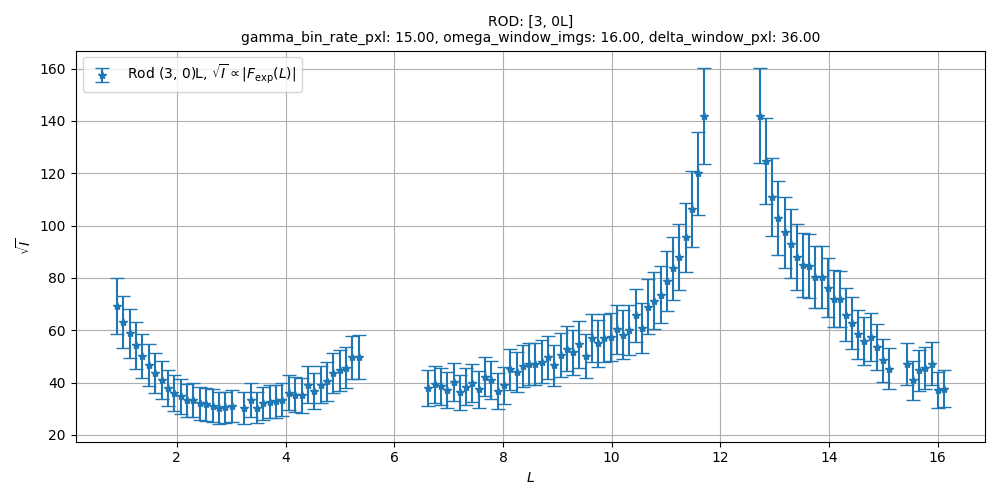

In [91]:
params_d = {
    'gamma_bin_rate_pxl': bin_gamma_rate, 
    'omega_window_imgs': bin_omega_rate, 
    'delta_window_pxl': bin_delta_rate
}

fig, ax = plt.subplots(figsize=(10, 5))
err_poisson = read_plot.I_error(I_sqrt_clean, f_low = 0.20, f_high = 0.1, gamma = 1, mode = "poisson")


# exclude the visible spikes
mask_spikes = (
    ((L_binned > 2.9) & (L_binned < 3.2) & (I_sqrt_clean > 40)) |
    ((L_binned > 15.1) & (L_binned < 15.5) & (I_sqrt_clean > 60))
)

mask_L = (L_binned > 0.05) & (~mask_spikes)

# Plot with error bars
ax.errorbar(
    L_binned[mask_L], I_sqrt_clean[mask_L], yerr=err_poisson[mask_L], fmt='*', capsize=5,
    label = f'Rod ({Bragg_peak[0]}, {Bragg_peak[1]})L, 'r'$\sqrt{I} \propto |F_{\mathrm{exp}}(L)|$')

# Labels
ax.set_xlabel(r'$L$')
ax.set_ylabel(r'$\sqrt{I}$')

# Combine Bragg peak info and parameters into a single title
bragg_info = f'ROD: [{Bragg_peak[0]}, {Bragg_peak[1]}L]'
formatted_params = ', '.join([f"{k}: {v:.2f}" for k, v in params_d.items()])  # Format each parameter on a new line
title = f"{bragg_info}\n{formatted_params}"

ax.set_title(title, fontsize=10)  # Adjust fontsize if needed
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

save_figs_dir = path_to_dir + dir_name + '/after_correction/images'

if save_figs_dir is not None:
    plt.savefig(f'{save_figs_dir}/rod{rod_name}L.png')
    plt.savefig(f'{save_figs_dir}/rod{rod_name}L.pdf')
    plt.savefig(f'{save_figs_dir}/rod{rod_name}L.svg')

In [92]:
L_binned_30 = L_binned[mask_L].copy()
I_sqrt_clean_30 = I_sqrt_clean[mask_L].copy()

In [93]:
H = np.array([Bragg_peak[0]]*len(I_sqrt_clean))
K = np.array([Bragg_peak[1]]*len(I_sqrt_clean))
intensity_mask = I_sqrt_clean > 0

gamma_binned = gamma_[gamma_centres][::signal_direction_sign]
corr_tot_corr2save = Ctot_full[gamma_centres][::signal_direction_sign]

delta_2save = delta_[delta_binned[intensity_mask].astype(int)]
theta_2save = theta_[theta_binned[intensity_mask].astype(int)]


sfactor_data_merged = {"H": H[intensity_mask], 
                       "K": K[intensity_mask],
                       "L": L_binned[intensity_mask],
                       "F": I_sqrt_clean[intensity_mask],
                       "Err_poisson": err_poisson[intensity_mask],
                      }

In [94]:
df2save = pd.DataFrame(data=sfactor_data_merged)
df2save

,H,K,L,F,Err_poisson
0,3,0,0.898942,69.282188,10.531679
1,3,0,1.016182,63.173412,9.862930
2,3,0,1.133415,58.793827,9.378623
3,3,0,1.250643,54.202221,8.865695
4,3,0,1.367865,50.142666,8.407025
...,...,...,...,...,...
110,3,0,15.662350,44.667732,7.779165
111,3,0,15.774232,45.650406,7.892738
112,3,0,15.886037,47.309792,8.083613
113,3,0,15.997766,37.010250,6.878013


In [274]:
df2save.to_csv(
    f"CTR_processed/P07_sapphire/integrated_rods/rod|{Bragg_peak[0]}{Bragg_peak[1]}L.txt",
    sep=" ",
    index=False,
    float_format="%.8f",
    encoding="utf-8"
)

### [1, 1, L]; 0-65 img range

In [95]:
Bragg_peak = (1, 1, None)

# creating folders 
rod_name = f'{Bragg_peak[0]}{Bragg_peak[1]}'
dir_name = 'P07_sapphire/rod|' + rod_name
path_to_dir = 'CTR_processed/'
dir_name_gamma = dir_name + '/before_correction/images/' + 'gamma_check/'

create = True
if create:
    read_plot.rod_create_nested_folders(dir_n = dir_name, path = path_to_dir, gamma_check = True)

In [ ]:
x_left = 2097
x_right = 2149
pixel_coord, rod_masked  = integration.rod_points_prep(mask_arr = Mask, x_l = x_left, x_r = x_right)
l_coord = np.median(l[:, :, x_left:x_right], axis=(0,2))

In [ ]:
current_beamstops_mask = beamstops_mask.copy()
current_beamstops_mask[:, :x_left] = 0
current_beamstops_mask[:, x_right:] = 0

plt.figure()
plt.imshow(current_beamstops_mask, vmin=0, vmax=255) 
plt.show()

In [ ]:
fig, ax = plt.subplot_mosaic([
    ['maxim', 'rodmsk', 'bmstp']  ], figsize=(13, 6))
ax['maxim'].imshow(max_pxl_im, vmax=220)
ax['rodmsk'].imshow(rod_masked, vmax=1)
ax['bmstp'].imshow(current_beamstops_mask, vmax=1)

ax['maxim'].set_title('Max pixel image')
ax['rodmsk'].set_title('Rod mask')
ax['bmstp'].set_title('Beam stops mask')
# fig.savefig(path_to_dir + dir_name + '/before_correction/images/integration_overview.png')

In [99]:
gamma_threshold = 0.05
if gamma_threshold is not None:
    gamma_threshold_index = integration.find_closest_value_index(gamma_, gamma_threshold)
    gamma_mask = gamma_ > gamma_[gamma_threshold_index]
    gamma_thresholded = gamma_[gamma_mask]
    pixel_coord_plot= pixel_coord[pixel_coord[:, 1] < gamma_threshold_index]
    l_coord = np.median(l[:, :, x_left:x_right], axis=(0,2))
    l_coord = l_coord[gamma_mask]
    gamma_shape = gamma_thresholded.shape[0]

In [101]:
y_pixels = np.array(list((set(pixel_coord_plot[:, 1]))))

signal_direction_sign = integration.signal_direction(y_pixels)
signal_direction_sign 

-1

In [ ]:
images_n = integration.get_signal_image_range(pixel_coord_plot)
images_n 

In [104]:
y_pixels = np.array(list((set(pixel_coord_plot[:, 1]))))

signal_direction_sign = integration.signal_direction(y_pixels)
signal_direction_sign 

-1

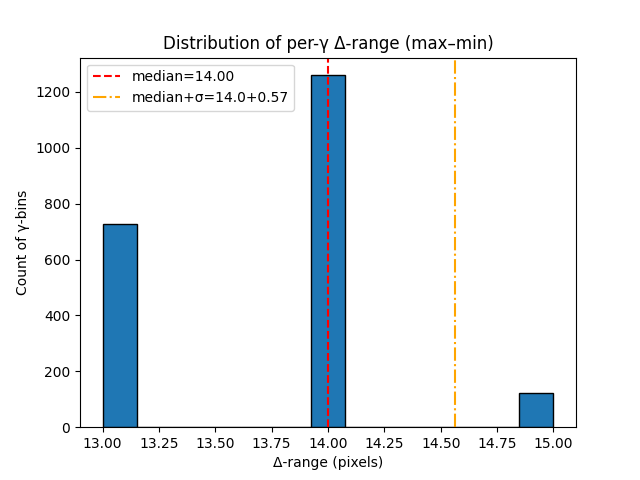

std = 0.565, median = 14.000, mean = 13.713
Recommended half Δ-range = 7 pixels;
 Δ-range = 15 pixels


(7, 15)

In [105]:
integration.get_delta_range(pixel_coord_plot=pixel_coord_plot, 
                gamma_pxl_range = gamma_pxl_range, 
                plot_flag = True, 
                sigma_factor = 1)

median(ω-range) = 2.00, median σ(ω) = 0.74
Recommended ω range = 3 images


3

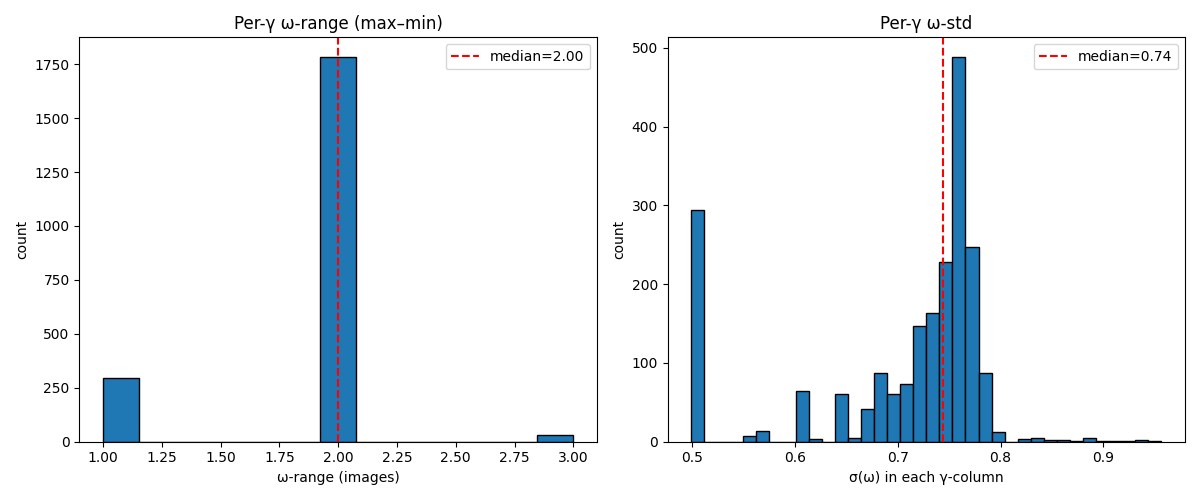

In [106]:
omega_half_range = integration.get_omega_range(pixel_coord_plot = pixel_coord_plot, 
                                                gamma_pxl_range = gamma_pxl_range, 
                                                plot_flag = True, 
                                                sigma_factor = 1)
omega_half_range

In [107]:
Ctot_full = integration.apply_corrections2D(delta_, gamma_, incidence_ang , rocking = True, return_map =True)

tmp1 = data
tmp1 = tmp1  / Ctot_full[None, :, :]

n_image = 205
delta_mid = 2112
g0 =np.int64(0), g1 =np.int64(15)


n_image = 204
delta_mid = 2113
g0 =np.int64(15), g1 =np.int64(30)


n_image = 203
delta_mid = 2114
g0 =np.int64(30), g1 =np.int64(45)


n_image = 202
delta_mid = 2115
g0 =np.int64(45), g1 =np.int64(60)


n_image = 201
delta_mid = 2115
g0 =np.int64(60), g1 =np.int64(75)


n_image = 200
delta_mid = 2116
g0 =np.int64(75), g1 =np.int64(90)


n_image = 199
delta_mid = 2117
g0 =np.int64(90), g1 =np.int64(105)


n_image = 198
delta_mid = 2118
g0 =np.int64(105), g1 =np.int64(120)


n_image = 197
delta_mid = 2119
g0 =np.int64(120), g1 =np.int64(135)


n_image = 196
delta_mid = 2119
g0 =np.int64(135), g1 =np.int64(150)


n_image = 195
delta_mid = 2120
g0 =np.int64(150), g1 =np.int64(165)


n_image = 194
delta_mid = 2120
g0 =np.int64(165), g1 =np.int64(180)


n_image = 193
delta_mid = 2121
g0 =np.int64(180), g1 =np.int64(195)


n_image = 193
delta_mid = 2122
g0 =np.int64(195), g1 =np.int64(210)


n_image = 192
delta_mid = 2123
g0 

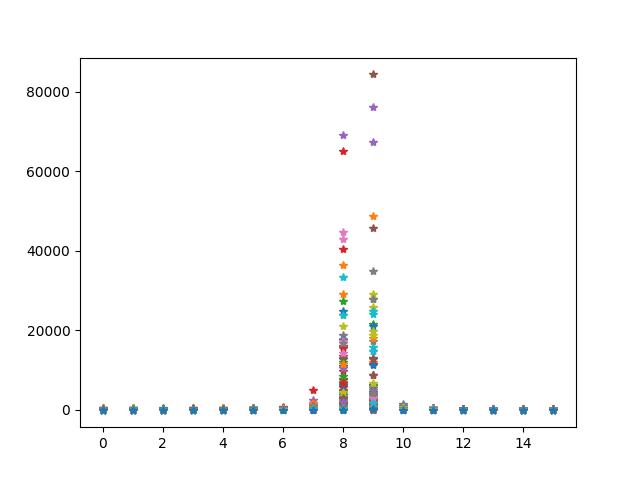

In [109]:
_output = integration.rocking_scan_integration(tmp1 , pixel_coord_plot, half_omega_r, half_delta_r,
                                   bin_gamma_rate, gamma_edges, gamma_centres, 
                                   FLAG = 'median', medfilt_kernel = 51, 
                                   SHOW_PLOT = True, PRINT_INTEGRATION_INFO = True)

# intensities_summed, int_slider_raw, int_slider_subtracted, bckgd_slider, omega_windows, gamma_windows = np.array(_output)
len(_output)
intensities_summed, int_slider_raw, int_slider_subtracted, bckgd_slider, omega_windows, gamma_windows, delta_windows = _output

In [110]:
len(intensities_summed), len(int_slider_raw), len(int_slider_subtracted), len(bckgd_slider), len(omega_windows), len(gamma_windows), len(delta_windows)

(147, 147, 147, 147, 141, 141, 141)

In [111]:
intensities_summed = np.array(intensities_summed, dtype='float32')[::signal_direction_sign ]

len(Q_binned), len(L_binned), len(intensities_summed), d_L_binned

(147, 147, 147, np.float64(0.11538604000982763))

In [112]:
np_int_slider_raw   = [np.asarray(i) for i in int_slider_raw   if i is not None]
np_int_bckgd_subtr  = [np.asarray(i) for i in int_slider_subtracted if i is not None]
np_bckgd_slider     = [np.asarray(i) for i in bckgd_slider     if i is not None]

In [114]:
gamma_windows_fullrange = [(i, min(i+bin_gamma_rate, data.shape[1])) for i in range(0, data.shape[1], bin_gamma_rate)]

gamma_mask = np.isin(np.array(gamma_windows_fullrange), np.array(gamma_windows)).all(axis=1)#[::signal_direction_sign]

In [116]:
gamma_mask = np.array(intensities_summed) > 0   # 
L_values = L_binned[::signal_direction_sign][gamma_mask]

In [117]:
d_L_binned,(np.diff(Q_binned / c_star[2])).mean()

(np.float64(0.11538604000982763), np.float64(0.11538604000982763))


... saving gif ... 

... done ... 



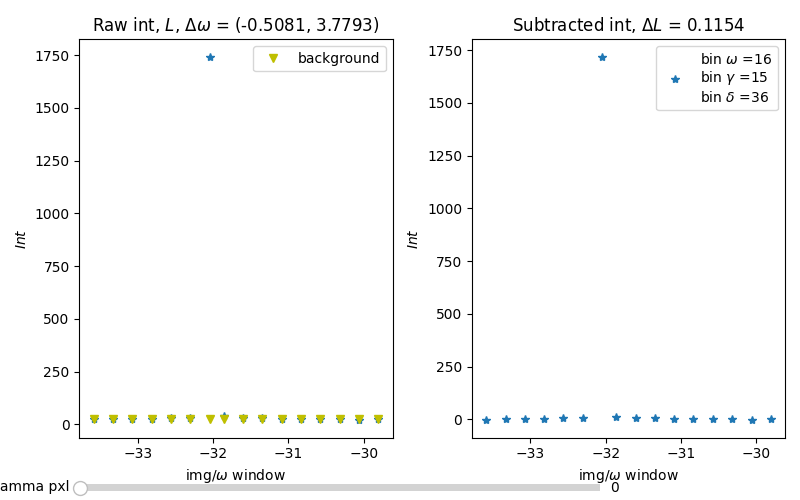

In [120]:
movie_path = path_to_dir + dir_name + '/before_correction/images/' + 'rocking_animation_' + f'bin_gamma_{bin_gamma_rate}_' + '.gif'
movie_path

bin_omega_rate = 2 * half_omega_r
bin_delta_rate = 2 * half_delta_r
theta_         = theta_ang                   # original incident-angle array

read_plot.om_profile_slider(np_int_slider_raw, np_int_bckgd_subtr, np_bckgd_slider,
                  omega_values=theta_, omega_windows=omega_windows,
                  L_values=L_binned[::signal_direction_sign][gamma_mask],
                  gamma_windows=gamma_windows,
                  bin_omega_rate=bin_omega_rate,
                  bin_gamma_rate=bin_gamma_rate,
                  bin_delta_rate=bin_delta_rate,
                  l_bin_rate=d_L_binned,
                  save_animate=True,
                  movie_path = movie_path,
                  fig_size=(8, 5));

In [ ]:
params_d = {
    'gamma_bin_rate_pxl': bin_gamma_rate, 
    'omega_window_imgs': bin_omega_rate, 
    'delta_window_pxl': bin_delta_rate
}

I_sqrt = np.sqrt(intensities_summed)
fig, ax = plt.subplots(figsize=(10, 5))
err_poisson = read_plot.I_error(I_sqrt, f_low = 0.20, f_high = 0.1, gamma = 1, mode = "poisson")

mask_L = L_binned > 0.2

# Plot with error bars
ax.errorbar(
    L_binned[mask_L], I_sqrt[mask_L], yerr=err_poisson[mask_L], fmt='*', capsize=5,
    label=f'Rod {Bragg_peak[0], Bragg_peak[1]}L, Structure Factor'
)

# Labels
ax.set_xlabel(r'$L$')
ax.set_ylabel(r'$\sqrt{I}$')

# Combine Bragg peak info and parameters into a single title
bragg_info = f'ROD: [{Bragg_peak[0]}{Bragg_peak[1]}L]'
formatted_params = ', '.join([f"{k}: {v:.2f}" for k, v in params_d.items()])  # Format each parameter on a new line
title = f"{bragg_info}\n{formatted_params}"

ax.set_title(title, fontsize=10)  # Adjust fontsize if needed
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

# save_figs_dir = path_to_dir + dir_name + '/before_correction/images'

# if save_figs_dir is not None:
#     plt.savefig(f'{save_figs_dir}/rod{rod_name}L.png')

In [123]:
row_fraction = current_beamstops_mask[:, x_left:x_right].astype(bool).mean(axis=1)[::signal_direction_sign]   

bin_frac, bin_edges, binnumber = binned_statistic(
        x      = np.arange(current_beamstops_mask.shape[0]),
        values = row_fraction,
        statistic = 'mean',
        bins   = gamma_edges)  

delta_binned, _, _ = binned_statistic(
    pixel_coord_plot[:,1],    # the values to bin by
    pixel_coord_plot[:,2],    # the δ-pixels
    statistic='median',
    bins=gamma_edges
                    )

theta_binned, _, _ = binned_statistic(
    pixel_coord_plot[:,1],
    pixel_coord_plot[:,0],
    statistic='median',
    bins=gamma_edges
                    ) 

delta_binned = delta_binned[::signal_direction_sign] 
theta_binned = theta_binned[::signal_direction_sign] 


threshold = 0.001                    # drop bins that are ≥threshold % masked
keep = bin_frac < threshold

In [124]:
# Ensure all arrays have identical length
assert keep.size == I_sqrt.size == L_binned.size

# NaN (or a NumPy masked array) so Matplotlib skips these bins
I_sqrt_clean = I_sqrt.copy()
# I_clean[~keep[::signal_direction_sign] ] = np.nan         # or:  I_clean = np.ma.array(I_sqrt, mask=~keep)
I_sqrt_clean[~keep] = np.nan

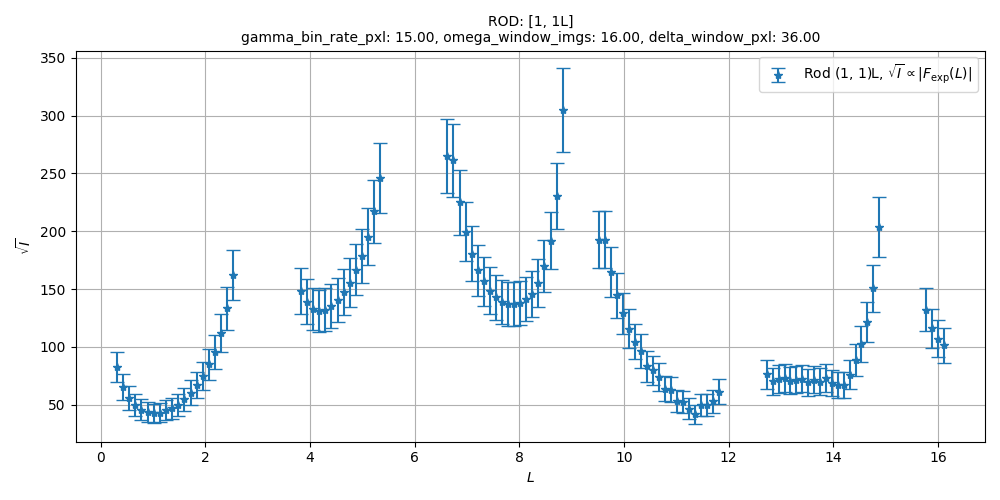

In [125]:
params_d = {
    'gamma_bin_rate_pxl': bin_gamma_rate, 
    'omega_window_imgs': bin_omega_rate, 
    'delta_window_pxl': bin_delta_rate
}

fig, ax = plt.subplots(figsize=(10, 5))
err_poisson = read_plot.I_error(I_sqrt_clean, f_low = 0.20, f_high = 0.1, gamma = 1, mode = "poisson")

mask_L = L_binned > 0.05

# Plot with error bars
ax.errorbar(
    L_binned[mask_L], I_sqrt_clean[mask_L], yerr=err_poisson[mask_L], fmt='*', capsize=5,
    label = f'Rod ({Bragg_peak[0]}, {Bragg_peak[1]})L, 'r'$\sqrt{I} \propto |F_{\mathrm{exp}}(L)|$')

# Labels
ax.set_xlabel(r'$L$')
ax.set_ylabel(r'$\sqrt{I}$')

# Combine Bragg peak info and parameters into a single title
bragg_info = f'ROD: [{Bragg_peak[0]}, {Bragg_peak[1]}L]'
formatted_params = ', '.join([f"{k}: {v:.2f}" for k, v in params_d.items()])  # Format each parameter on a new line
title = f"{bragg_info}\n{formatted_params}"

ax.set_title(title, fontsize=10)  # Adjust fontsize if needed
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

save_figs_dir = path_to_dir + dir_name + '/after_correction/images'

if save_figs_dir is not None:
    plt.savefig(f'{save_figs_dir}/rod{rod_name}L.png')
    plt.savefig(f'{save_figs_dir}/rod{rod_name}L.pdf')
    plt.savefig(f'{save_figs_dir}/rod{rod_name}L.svg')

In [126]:
L_binned_11 = L_binned.copy()
I_sqrt_clean_11 = I_sqrt_clean.copy()

In [127]:
H = np.array([Bragg_peak[0]]*len(I_sqrt_clean))
K = np.array([Bragg_peak[1]]*len(I_sqrt_clean))
intensity_mask = I_sqrt_clean > 0

gamma_binned = gamma_[gamma_centres][::signal_direction_sign]
corr_tot_corr2save = Ctot_full[gamma_centres][::signal_direction_sign]

delta_2save = delta_[delta_binned[intensity_mask].astype(int)]
theta_2save = theta_[theta_binned[intensity_mask].astype(int)]


sfactor_data_merged = {"H": H[intensity_mask], 
                       "K": K[intensity_mask],
                       "L": L_binned[intensity_mask],
                       "F": I_sqrt_clean[intensity_mask],
                       "Err_poisson": err_poisson[intensity_mask],
                      }

In [128]:
df2save = pd.DataFrame(data=sfactor_data_merged)
df2save

,H,K,L,F,Err_poisson
0,1,1,0.312690,82.715591,13.102918
1,1,1,0.429946,65.003998,11.109032
2,1,1,0.547200,55.704075,10.028668
3,1,1,0.664451,49.724094,9.316855
4,1,1,0.781699,45.711983,8.829824
...,...,...,...,...,...
94,1,1,14.877100,203.609329,25.860536
95,1,1,15.774232,132.250961,18.439475
96,1,1,15.886037,115.927963,16.707042
97,1,1,15.997766,107.038437,15.754565


In [322]:
df2save.to_csv(
    f"CTR_processed/P07_sapphire/integrated_rods/rod|{Bragg_peak[0]}{Bragg_peak[1]}L.txt",
    sep=" ",
    index=False,
    float_format="%.8f",
    encoding="utf-8"
)